# Model Building and Evaluation

- Loaded the processed dataset prepared during the data preprocessing and feature engineering stage.

- Separated the dataset into **features (X)** and the **target variable (y)**.

- The target variable is **Churn Label**, which the machine learning models will predict.

- The remaining features are used as input variables for predicting customer churn.

- The modelling dataset was checked to ensure that **target leakage columns** such as Churn Value, Churn Score and Churn Reason are not used as predictors.

- This prepares the dataset for the next step: **splitting the data into training and testing sets**.

In [33]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv(r"C:\Users\RATHICK A\OneDrive\Desktop\data analytics\data\telco_customer_churn_processed_for_modelling.csv")

In [35]:
df.shape

(7043, 49)

In [36]:
df.head()

,Count,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Contract_Month-to-month,Contract_One year,Contract_Two year,Payment Method_Bank transfer (automatic),Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Tenure Group,Total Services,Support Services
0,1,90003,33.964131,-118.272783,1,0,0,0,2,1,...,1,0,0,0,0,0,1,New,3,2
1,1,90005,34.059281,-118.307420,0,0,0,1,2,1,...,1,0,0,0,0,1,0,New,1,0
2,1,90006,34.048013,-118.293953,0,0,0,1,8,1,...,1,0,0,0,0,1,0,New,5,1
3,1,90010,34.062125,-118.315709,0,0,1,1,28,1,...,1,0,0,0,0,1,0,Medium,6,2
4,1,90015,34.039224,-118.266293,1,0,0,1,49,1,...,1,0,0,1,0,0,0,Long-term,6,2


### Separating Features and Target

- **X** contains the customer features that will be given to the model.

- **y** contains the actual churn outcome that the model needs to predict.

- Separating them is necessary because the model learns the relationship between the input features (X) and the target (y).

In [37]:
df = df.drop(columns=["Tenure Group"])

In [38]:
y = df["Churn Label"]
X = df.drop("Churn Label", axis=1)

In [39]:
X.shape, y.shape

((7043, 47), (7043,))

### Train-Test Split

- Split the dataset into **training and testing sets**.

- The **training set** is used to train the machine learning model.

- The **testing set** is kept separate and used to evaluate how well the trained model performs on unseen data.

- We use `stratify=y` to maintain approximately the same proportion of churned and non-churned customers in both sets.

- An **80:20 split** is used, where 80% of the data is used for training and 20% for testing.

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 47)
X_test: (1409, 47)
y_train: (5634,)
y_test: (1409,)


### Feature Scaling

- Some numerical features have very different ranges. For example, Tenure Months, Monthly Charges and CLTV have different scales.

- Feature scaling puts numerical variables on a comparable scale so that features with larger numerical values do not disproportionately influence models that are sensitive to feature magnitude.

- We use `StandardScaler` to standardize the selected numerical features.

- The scaler is fitted **only on the training data** to avoid information from the test set leaking into the training process.

- The same transformation is then applied to the test data.

In [42]:
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

In [43]:
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

## Logistic Regression – Model Training

- Logistic Regression was used as the **baseline classification model** for predicting customer churn.

- The model was trained using the **training dataset (`X_train`, `y_train`)**.

- Logistic Regression is suitable for this problem because **Churn is a binary classification target**.

- The model learns the relationship between customer features and the probability of churn.

- The model successfully converged after increasing the maximum number of iterations to **3000**.

- The trained model will now be used to predict churn on the **unseen test dataset** and evaluate its performance.

In [54]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=3000, random_state=42)

In [55]:
y_pred_log = log_model.predict(X_test)

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))

cm = confusion_matrix(y_test, y_pred_log)
print("\nConfusion Matrix:")
print(cm)

y_prob_log = log_model.predict_proba(X_test)[:, 1]
print("\nROC-AUC   :", roc_auc_score(y_test, y_prob_log))

Accuracy : 0.8055358410220014
Precision: 0.6497005988023952
Recall   : 0.5802139037433155
F1 Score : 0.6129943502824858

Confusion Matrix:
[[918 117]
 [157 217]]

ROC-AUC   : 0.8491436100131752


## Logistic Regression – Results

- The Logistic Regression model achieved an accuracy of **80.55%** on the test dataset.

- The model achieved a **precision of 64.97%**, meaning that around 65% of customers predicted as churners actually churned.

- The **recall was 58.02%**, meaning the model identified around 58% of the customers who actually churned.

- The **F1-score was 61.30%**, providing a balance between precision and recall.

- The model achieved a **ROC-AUC score of 84.91%**, indicating good overall ability to distinguish between churned and non-churned customers.

- The confusion matrix shows that the model correctly identified **217 churners**, while **157 actual churners were misclassified as non-churners**.

- Overall, Logistic Regression provides a useful **baseline model**, but there is room for improvement, particularly in identifying actual churners.

## Random Forest – Model Training

- Random Forest is used as a second model to predict customer churn.
- It can capture **non-linear relationships and feature interactions** better than Logistic Regression.
- The model is trained on the same training data and will be evaluated using the same metrics for a fair comparison.

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [58]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [59]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(cm_rf)

print("\nROC-AUC   :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.794180269694819
Precision: 0.6448275862068965
Recall   : 0.5
F1 Score : 0.5632530120481928

Confusion Matrix:
[[932 103]
 [187 187]]

ROC-AUC   : 0.8395786509597251


## Model Comparison – Logistic Regression vs Random Forest

- Logistic Regression performed better than Random Forest across all evaluated metrics.
- Logistic Regression achieved higher accuracy, recall, F1-score and ROC-AUC.
- The higher recall of Logistic Regression means it identified more actual churners.
- Based on the current results, Logistic Regression is the stronger model between the two.

## Gradient Boosting – Model Training

- Gradient Boosting is used as another classification model for churn prediction.
- It builds models sequentially, with each new model trying to correct the errors of the previous ones.
- Its performance will be compared with the previous models using the same evaluation metrics.

In [60]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [61]:
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

In [62]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))

cm_gb = confusion_matrix(y_test, y_pred_gb)
print("\nConfusion Matrix:")
print(cm_gb)

print("\nROC-AUC   :", roc_auc_score(y_test, y_prob_gb))

Accuracy : 0.7991483321504613
Precision: 0.6491803278688525
Recall   : 0.5294117647058824
F1 Score : 0.5832106038291606

Confusion Matrix:
[[928 107]
 [176 198]]

ROC-AUC   : 0.8517915730191945


## Model Comparison

- Three classification models were evaluated: Logistic Regression, Random Forest and Gradient Boosting.
- Logistic Regression achieved the highest accuracy, recall and F1-score.
- Gradient Boosting achieved the highest ROC-AUC score.
- Random Forest performed lower than the other two models across the main evaluation metrics.
- Based on the current results, **Logistic Regression is the strongest overall model**, while Gradient Boosting shows slightly better overall ranking ability based on ROC-AUC.

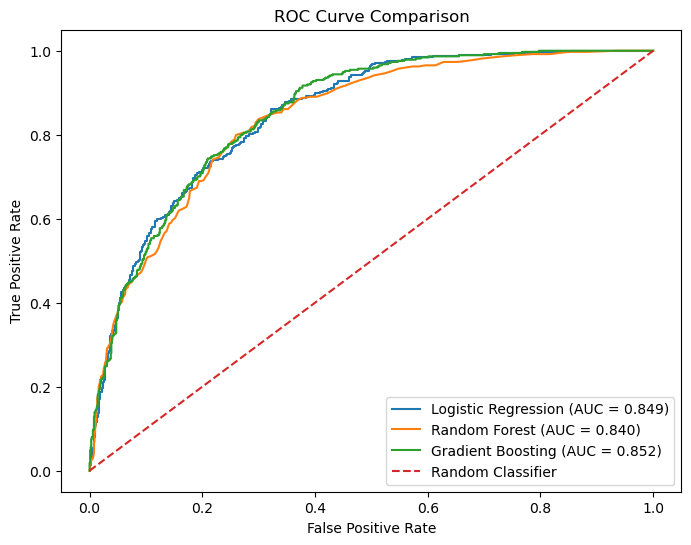

In [63]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log, tpr_log,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.3f})"
)

plt.plot(
    fpr_rf, tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})"
)

plt.plot(
    fpr_gb, tpr_gb,
    label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, y_prob_gb):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## ROC Curve Comparison

- ROC curves are used to compare how well the models distinguish between churned and non-churned customers across different classification thresholds.
- The **AUC (Area Under the Curve)** summarizes this performance, with a higher value indicating better overall discrimination.
- The ROC curves of all three models are compared to identify their relative performance.

In [64]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [0.8055, 0.7942, 0.7991],
    "Precision": [0.6497, 0.6448, 0.6492],
    "Recall": [0.5802, 0.5000, 0.5294],
    "F1 Score": [0.6130, 0.5633, 0.5832],
    "ROC-AUC": [0.8491, 0.8396, 0.8518]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8055,0.6497,0.5802,0.6130,0.8491
1,Random Forest,0.7942,0.6448,0.5000,0.5633,0.8396
2,Gradient Boosting,0.7991,0.6492,0.5294,0.5832,0.8518


## Final Model Selection

- Three models were compared: Logistic Regression, Random Forest and Gradient Boosting.
- Logistic Regression achieved the highest **accuracy, recall and F1-score**.
- Gradient Boosting achieved the highest **ROC-AUC**.
- Random Forest showed the lowest overall performance among the three models.
- Since identifying actual churners is important, **recall and F1-score** are given more importance along with overall performance.
- Therefore, **Logistic Regression is selected as the final model** based on the current evaluation results.

In [65]:
import xgboost as xgb

print(xgb.__version__)

ModuleNotFoundError: No module named 'xgboost'

In [66]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   - -------------------------------------- 2.4/48.9 MB 11.9 MB/s eta 0:00:04
   --- ------------------------------------ 4.7/48.9 MB 11.8 MB/s eta 0:00:04
   ----- ---------------------------------- 7.1/48.9 MB 11.9 MB/s eta 0:00:04
   ------- -------------------------------- 9.7/48.9 MB 11.9 MB/s eta 0:00:04
   --------- ------------------------------ 12.1/48.9 MB 11.9 MB/s eta 0:00:04
   ----------- ---------------------------- 14.4/48.9 MB 11.9 MB/s eta 0:00:03
   ------------- -------------------------- 16.8/48.9 MB 11.8 MB/s eta 0:00:03
   --------------- ------------------------ 19.4/48.9 MB 11.9 MB/s eta 0:00:03
   ----------------- ---------------------- 22.0/48.9 MB 11.8 MB/s eta 0:00:03
   ------------------- -------------------- 24.4/48.9 MB 11.8 MB/s eta 0:00:03
   --------------------- ------------------ 26.7/48.9 MB 11.8 MB/s eta 0:00:02
   ----------------------- ---------------- 29.4/48.9 MB 11.8 MB/

In [67]:
import xgboost as xgb

print(xgb.__version__)

3.4.1


## XGBoost – Prediction

- The trained XGBoost model is used to predict churn for the unseen test dataset.
- These predictions will be used to evaluate the model's performance using accuracy, precision, recall, F1-score and ROC-AUC.

In [68]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [69]:
y_pred_xgb = xgb_model.predict(X_test)

## XGBoost – Model Evaluation

- The XGBoost model is evaluated using the same metrics as the previous models.
- Its performance is compared with Logistic Regression, Random Forest and Gradient Boosting to determine whether it improves churn prediction.

In [70]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:")
print(cm_xgb)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\nROC-AUC   :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.7984386089425124
Precision: 0.6470588235294118
Recall   : 0.5294117647058824
F1 Score : 0.5823529411764706

Confusion Matrix:
[[927 108]
 [176 198]]

ROC-AUC   : 0.8510630602702214


## XGBoost – Results

- XGBoost achieved an accuracy of **79.84%**, with a recall of **52.94%** and an F1-score of **58.24%**.
- Its ROC-AUC score was **85.11%**, showing good ability to distinguish between churned and non-churned customers.
- However, XGBoost did not improve the accuracy, recall or F1-score of the Logistic Regression baseline.
- Therefore, the current XGBoost configuration does not provide an overall improvement over the baseline model.

## Logistic Regression – Hyperparameter Tuning

- Hyperparameter tuning is used to find better model settings instead of relying on default values.
- Different regularization strengths are tested using cross-validation on the training data.
- The best configuration is then evaluated on the unseen test set.

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=3000, random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Best Parameters: {'C': 100, 'solver': 'lbfgs'}
Best CV F1: 0.6226977940923686


In [72]:
best_log_model = grid_search.best_estimator_

y_pred_tuned = best_log_model.predict(X_test)
y_prob_tuned = best_log_model.predict_proba(X_test)[:, 1]

## Tuned Logistic Regression – Test Evaluation

- The best hyperparameters identified through cross-validation are used to train the final Logistic Regression model.
- The tuned model is evaluated on the unseen test dataset.
- Its performance is compared with the original Logistic Regression baseline to check whether tuning improved the results.

In [73]:
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nROC-AUC   :", roc_auc_score(y_test, y_prob_tuned))

Accuracy : 0.8062455642299503
Precision: 0.6507462686567164
Recall   : 0.5828877005347594
F1 Score : 0.614950634696756

Confusion Matrix:
[[918 117]
 [156 218]]

ROC-AUC   : 0.8493011961042651


## Tuned Logistic Regression – Results

- Hyperparameter tuning produced a small improvement over the baseline Logistic Regression model.
- Accuracy increased from **80.55% to 80.62%**.
- Recall increased from **58.02% to 58.29%**, allowing the model to identify slightly more actual churners.
- F1-score increased from **61.30% to 61.50%**.
- ROC-AUC remained almost unchanged at approximately **84.93%**.
- The improvement is modest, but the tuned Logistic Regression model currently provides the best overall classification performance among the tested models.

## Threshold Optimization

- Logistic Regression normally classifies a customer as churned when the predicted probability is at least **0.50**.
- Instead of assuming 0.50 is optimal, different thresholds are tested.
- The threshold producing the highest **F1-score** is selected.
- This helps balance the model's precision and recall when identifying potential churners.

In [75]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.20, 0.81, 0.01)

f1_scores = []

for threshold in thresholds:
    y_pred_temp = (y_prob_tuned >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_temp))

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold: 0.37000000000000016
Best F1 Score: 0.6347305389221557


## Optimized Threshold – Results

- The default classification threshold of 0.50 was adjusted to **0.37** based on the threshold that produced the highest F1-score.
- The optimized threshold increased the F1-score from **61.50% to 63.47%**.
- This indicates a better balance between identifying actual churners and limiting false positive predictions.
- The remaining evaluation metrics will be calculated using the optimized threshold to determine its effect on overall model performance.

In [76]:
y_pred_threshold = (y_prob_tuned >= best_threshold).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_threshold))
print("Precision:", precision_score(y_test, y_pred_threshold))
print("Recall   :", recall_score(y_test, y_pred_threshold))
print("F1 Score :", f1_score(y_test, y_pred_threshold))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_threshold))

Accuracy : 0.7835344215755855
Precision: 0.5748373101952278
Recall   : 0.7085561497326203
F1 Score : 0.6347305389221557

Confusion Matrix:
[[839 196]
 [109 265]]


## Optimized Threshold – Evaluation

- Reducing the classification threshold from 0.50 to 0.37 increased recall from **58.29% to 70.86%**.
- The model therefore identifies substantially more actual churners.
- The F1-score also improved from **61.50% to 63.47%**.
- However, accuracy decreased from **80.62% to 78.35%**, while precision decreased from **65.07% to 57.48%**.
- This represents a trade-off between identifying more potential churners and generating more false-positive predictions.
- For a churn-retention application, the lower threshold may be preferable when **missing a potential churner is more costly than contacting a non-churning customer**.

## Threshold vs Precision, Recall and F1-score

This graph shows how precision, recall and F1-score change as the classification threshold is varied. It helps visualize the trade-off between identifying more churners and reducing false-positive predictions.

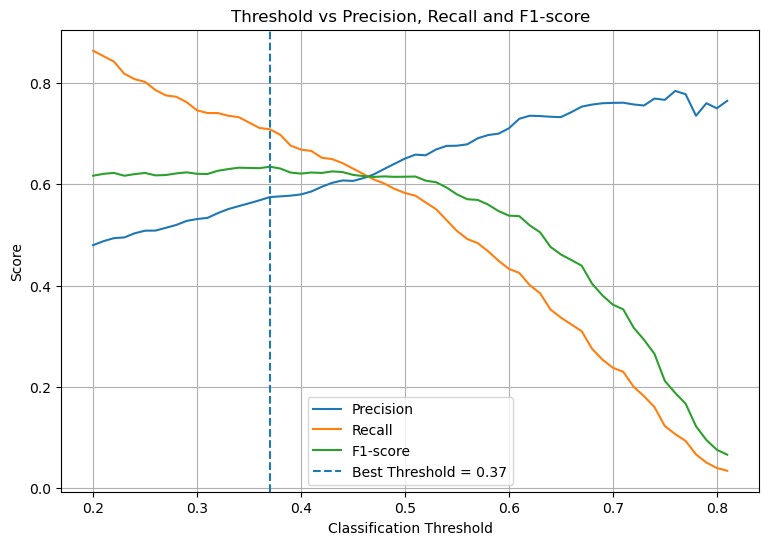

In [77]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

precision_scores = []
recall_scores = []
f1_scores = []

for threshold in thresholds:
    y_pred_temp = (y_prob_tuned >= threshold).astype(int)

    precision_scores.append(precision_score(y_test, y_pred_temp))
    recall_scores.append(recall_score(y_test, y_pred_temp))
    f1_scores.append(f1_score(y_test, y_pred_temp))

plt.figure(figsize=(9, 6))

plt.plot(thresholds, precision_scores, label="Precision")
plt.plot(thresholds, recall_scores, label="Recall")
plt.plot(thresholds, f1_scores, label="F1-score")

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision, Recall and F1-score")
plt.legend()
plt.grid(True)
plt.show()

## XGBoost – Feature Importance

- Feature importance is used to identify the features that contribute most to the model's predictions.
- This helps understand which customer characteristics are most influential in churn prediction.
- The most important features can provide useful business insights for customer retention strategies.

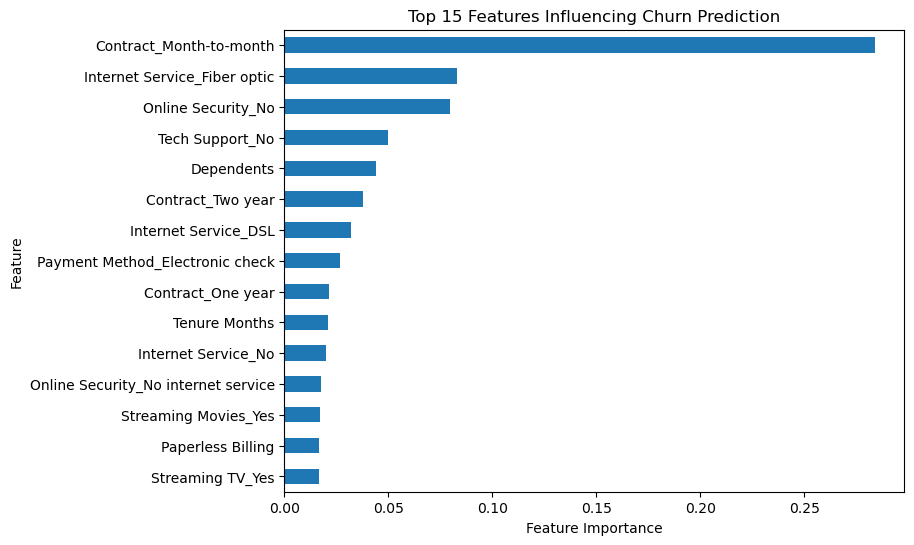

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Top 15 Features Influencing Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

## Feature Importance – Key Insights

- Contract type, especially month-to-month contracts, is the most influential feature in the XGBoost model.
- Internet service type, online security, and tech support are also important predictors.
- Tenure, dependents, payment method and billing preferences contribute to churn prediction.
- Feature importance indicates how strongly a feature is used by the model, but does not indicate causation or whether the feature increases or decreases churn.
- These insights can help identify customer segments that may require targeted retention strategies.